# TopSBM: Topic Modeling with Stochastic Block Models

A basic tutorial.


In [1]:
import os,sys
sys.path.append("../dataTutorial/")
sys.path.append("../../hSBM_Topicmodel/")
import graph_tool.all as gt
import sbmtm as sbmtm
import pylab as plt
import os

import numpy as np
import pandas as pd
import scipy as sp

# Setup: Load a corpus

1) We have a list of documents, each document contains a list of words.

2) We have a list of document titles (optional) 

The example corpus consists of 63 articles from Wikipedia taken from 3 different categories (Experimental Physics, Chemical Physics, and Computational Biology).



In [27]:
path_data = '../dataTutorial/'
dataname= "wikipedia"#"constitutions" #"wikipedia" #arxiv,constitutions
## texts
fname_data = dataname+'-texts.txt'
filename = os.path.join(path_data,fname_data)

with open(filename,'r', encoding = 'utf8') as f:
    x = f.readlines()
texts = [h.split() for h in x]

## titles
fname_data = dataname+'-titles.txt'
filename = os.path.join(path_data,fname_data)

with open(filename,'r', encoding = 'utf8') as f:
    x = f.readlines()
titles = [h.strip('\n') for h in x]


In [28]:
print(len(titles),len(texts))

120 120


# Fitting the model

In [29]:
import time

In [30]:
start = time.time()
## we create an instance of the sbmtm-class
model = sbmtm.sbmtm()

## we have to create the word-document network from the corpus
model.make_graph(texts,documents=titles)

end = time.time()
print(end - start)

## we can also skip the previous step by saving/loading a graph
# model.save_graph(filename = 'graph.xml.gz')
# model.load_graph(filename = 'graph.xml.gz')

## fit the model
gt.seed_rng(32) ## seed for graph-tool's random number generator --> same results
model.fit()

end2 = time.time()
print(end2 - end)

0.2824234962463379
<NestedBlockState object, with base <BlockState object with 11658 blocks (329 nonempty), degree-corrected, for graph <Graph object, undirected, with 11658 vertices and 62803 edges, 2 internal vertex properties, 1 internal edge property, at 0x792a940c3230>, at 0x792a9416e840>, and 5 levels of sizes [(11658, 329), (329, 49), (49, 10), (10, 2), (2, 1)] at 0x792a941162d0>
18.997368335723877


In [31]:
model.save_model("results/"+dataname+"-fitted.pickle")
#model.load_model("../results/xenophonANDplato.pickle")

In [32]:
model.print_summary()

l: 0, N: 11658, B: 329
l: 1, N: 329, B: 49
l: 2, N: 49, B: 10
l: 3, N: 10, B: 2
l: 4, N: 2, B: 1


In [33]:
model.clusters(l=1,n=100)

{0: [('Adenosine triphosphate', 1.0),
  ('Ankyrin repeat', 1.0),
  ('Glycolysis', 1.0),
  ('NDPCP', 1.0),
  ('Protein structure prediction', 1.0)],
 1: [('Small nuclear RNA', 1.0),
  ('Bcl-2 homologous antagonist killer', 1.0),
  ('Gene expression', 1.0),
  ('Messenger RNA', 1.0),
  ('Central dogma of molecular biology', 1.0),
  ('Alternative splicing', 1.0),
  ('Transcription (biology)', 1.0),
  ('Translation (biology)', 1.0),
  ('Bcl-2-associated X protein', 1.0),
  ('Cell nucleus', 1.0),
  ('Apoptosis', 1.0)],
 2: [('Multipole density formalism', 1.0),
  ('Fourier analysis', 1.0),
  ('Direct methods (crystallography)', 1.0),
  ('Topological defect', 1.0),
  ('X-ray crystallography', 1.0),
  ('Discrete Fourier transform', 1.0)],
 3: [('Space group', 1.0),
  ('Plücker embedding', 1.0),
  ('Erlangen program', 1.0),
  ('Continuous symmetry', 1.0),
  ('Haar measure', 1.0),
  ('Virasoro algebra', 1.0),
  ('Grassmannian', 1.0),
  ('Group contraction', 1.0),
  ('Motion (geometry)', 1.0),
  

In [34]:
model.topics(l=2,n=20)

{0: [('the', 0.21185121520317052),
  ('be', 0.12260898629613713),
  ('of', 0.12186410733896767),
  ('a', 0.09937449267058206),
  ('in', 0.06565439526333382),
  ('and', 0.061958649668146876),
  ('to', 0.05402282385522609),
  ('by', 0.024714701809673875),
  ('it', 0.018812968533638924),
  ('an', 0.016463734899489088),
  ('have', 0.01416224991643986),
  ('which', 0.013446020149930765),
  ('from', 0.011278231389963233),
  ('not', 0.009253688583297523),
  ('such', 0.0073150933486129015),
  ('also', 0.007162297665090961),
  ('these', 0.006274172754619682),
  ('other', 0.005405147304588645),
  ('there', 0.004946760254022824),
  ('but', 0.00468891753807955)],
 1: [('molecule', 0.035122370115929585),
  ('sequence', 0.03280377844568484),
  ('process', 0.028595963933018463),
  ('expression', 0.02310004293688278),
  ('occur', 0.01794761700300558),
  ('measure', 0.017861743237440962),
  ('class', 0.015113782739373121),
  ('cause', 0.013739802490339202),
  ('molecular', 0.013482181193645342),
  ('bo

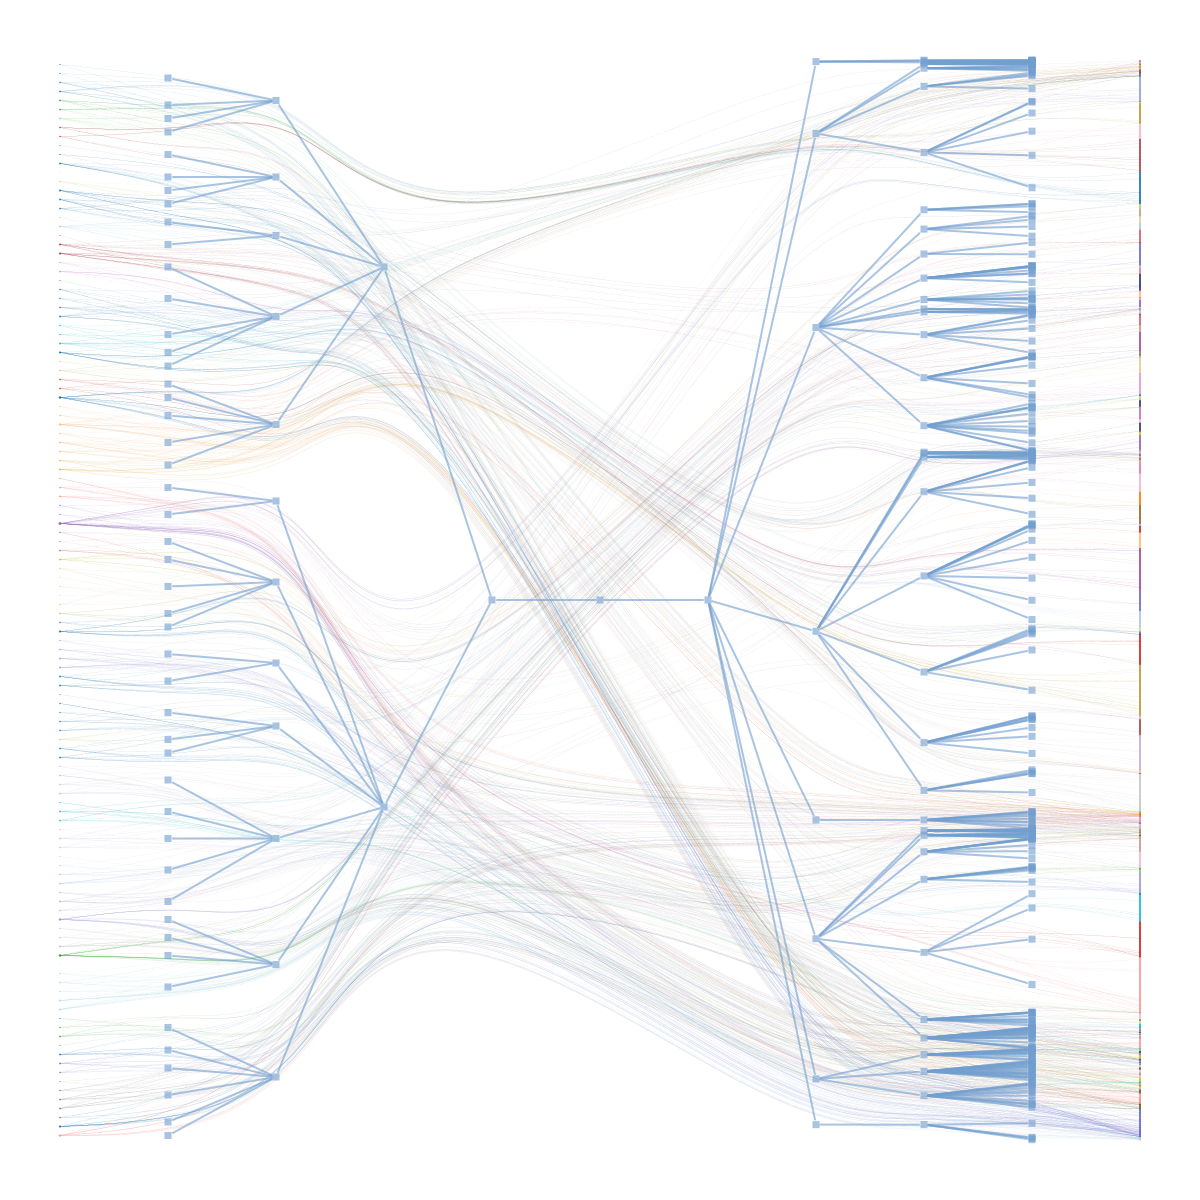

In [35]:
model.plot()

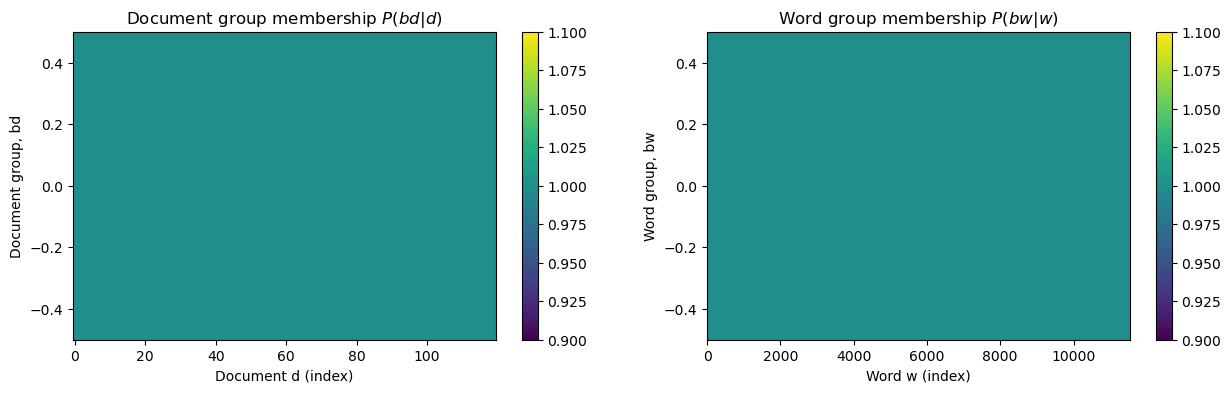

In [36]:
import pylab as plt
p_td_d,p_tw_w = model.group_membership(l=3)

plt.figure(figsize=(15,4))
plt.subplot(121)
plt.imshow(p_td_d,origin='lower',aspect='auto',interpolation='none')
plt.title(r'Document group membership $P(bd | d)$')
plt.xlabel('Document d (index)')
plt.ylabel('Document group, bd')
plt.colorbar()

plt.subplot(122)
plt.imshow(p_tw_w,origin='lower',aspect='auto',interpolation='none')
plt.title(r'Word group membership $P(bw | w)$')
plt.xlabel('Word w (index)')
plt.ylabel('Word group, bw')
plt.colorbar()

In [37]:
## select a document (by its index)
i_doc =0
print(model.documents[i_doc])
## get a list of tuples (topic-index, probability)
model.topicdist(i_doc,l=2)

Adenosine triphosphate


[(0, 0.39378969654199014),
 (1, 0.0529287226534933),
 (2, 0.11750176429075512),
 (3, 0.31439661256175017),
 (4, 0.04410726887791108),
 (5, 0.05998588567395907),
 (6, 0.011644318983768526),
 (7, 0.0056457304163726185)]

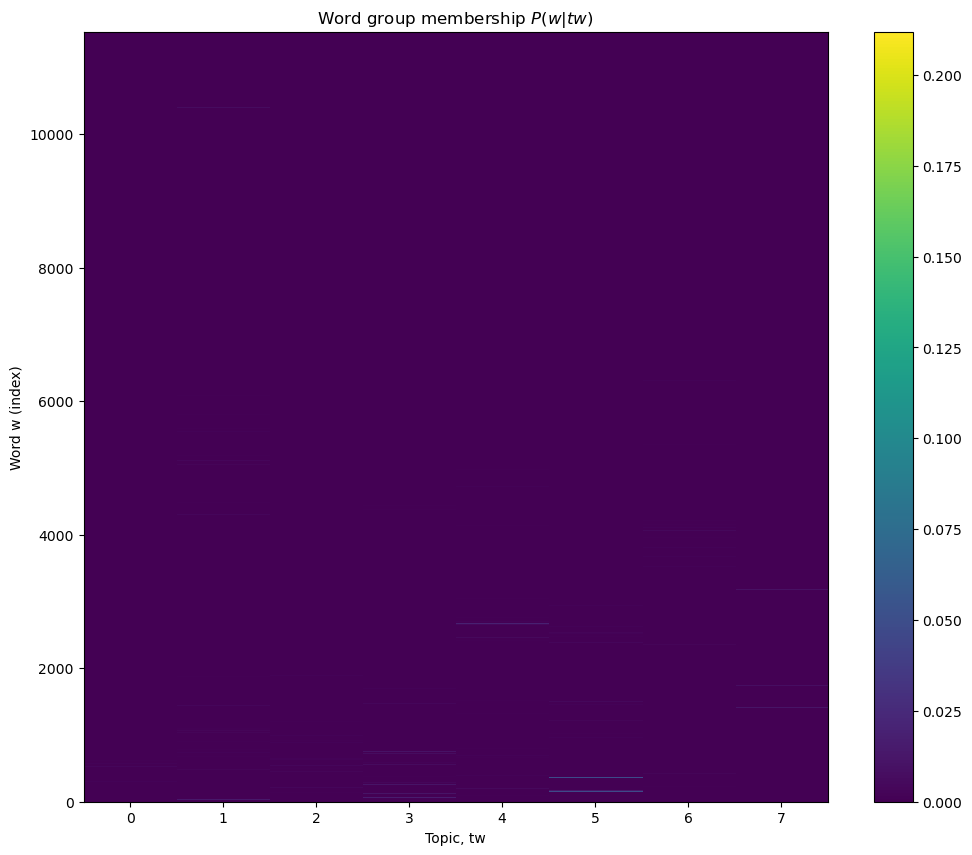

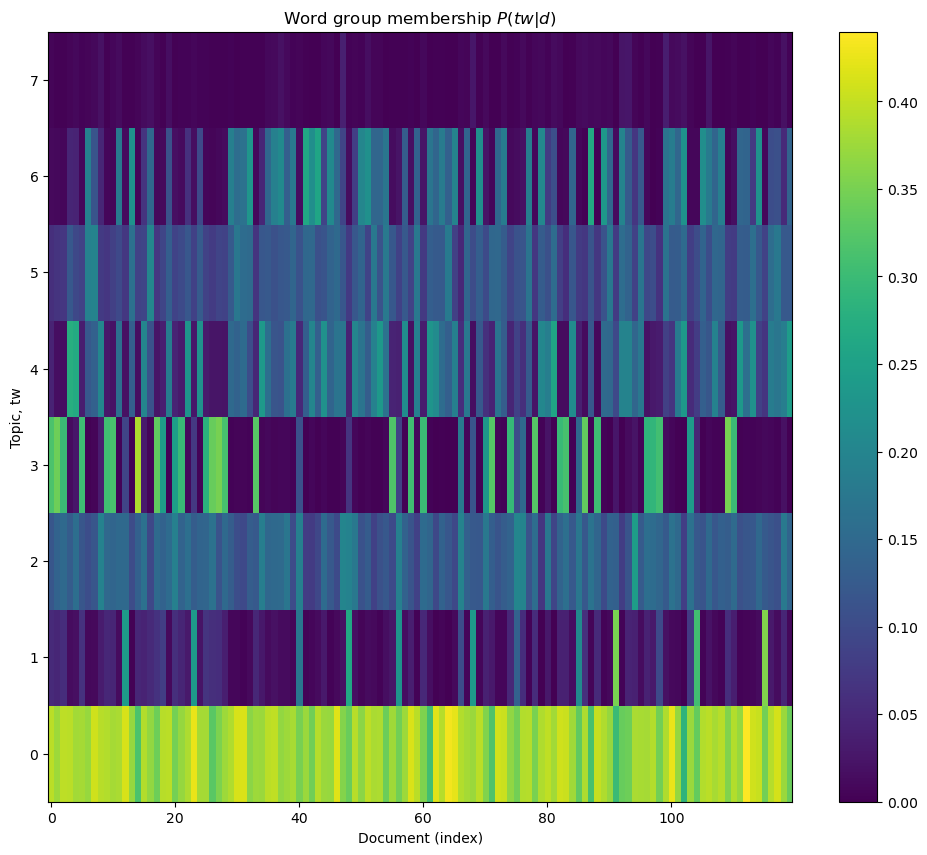

In [38]:
model.plot_topic_dist(l=2)

In [42]:
model.pmi_td_tw(l=0)

/home/ega/gitRepos/ATAP/topsbm/../../hSBM_Topicmodel/sbmtm.py:660: RuntimeWarning: invalid value encountered in divide
  pmi_td_tw = np.log(p_tw_td/(p_td*p_tw[:,np.newaxis])).T
/home/ega/gitRepos/ATAP/topsbm/../../hSBM_Topicmodel/sbmtm.py:660: RuntimeWarning: divide by zero encountered in log
  pmi_td_tw = np.log(p_tw_td/(p_td*p_tw[:,np.newaxis])).T


array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])

In [46]:
model.group_to_group_mixture(l=2)

array([[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, nan, nan, nan]])

In [55]:
p_tw_d=model.get_groups(l=2)['p_tw_d']

In [60]:
p_tw_d[5]

array([0.05998589, 0.06542056, 0.06907788, 0.1215028 , 0.09601182,
       0.08745554, 0.1924869 , 0.19672351, 0.07550886, 0.07030978,
       0.08372365, 0.09762172, 0.07082026, 0.16342412, 0.08664163,
       0.0926652 , 0.20257753, 0.06969541, 0.09107551, 0.13079223,
       0.08803222, 0.09938603, 0.12010542, 0.08519553, 0.1265081 ,
       0.08703008, 0.07651913, 0.08979445, 0.0863061 , 0.1247216 ,
       0.17394305, 0.15633188, 0.15261538, 0.06681223, 0.11891805,
       0.12242137, 0.10864979, 0.11897772, 0.12369338, 0.14426523,
       0.11007696, 0.14658926, 0.14797136, 0.10674574, 0.11424219,
       0.13923286, 0.15018773, 0.11947319, 0.07555556, 0.11864997,
       0.14234748, 0.0884434 , 0.17553191, 0.11230329, 0.17758563,
       0.12096774, 0.08580106, 0.12292683, 0.08739496, 0.1765153 ,
       0.07383101, 0.13069909, 0.12473573, 0.12381404, 0.1797862 ,
       0.08277405, 0.04923903, 0.14366883, 0.10204696, 0.13208685,
       0.09880143, 0.1464497 , 0.1488764 , 0.12783696, 0.08954